# Day 023 · 价差/流动性/冲击成本 · 中国版
**Spread & Impact** · 阶段 P1 · 量化基础

> 价差不只是交易所收费的副产物 — 它反映了做市商承担风险的真实成本。今天我们做三件事:① 把价差拆解成三个组成 — 订单处理成本、库存持有成本、信息不对称成本(adverse selection),理解为什么活跃股 spread 永远不会归零;② 用 Kyle 1985 的 lambda 模型把『单量推动价格』表达成线性函数,并通过模拟数据估算实际市场的 lambda 值;③ 验证 Almgren-Chriss 的平方根冲击律 — 单量翻 100 倍,冲击只翻 10 倍,这是大单交易算法 TWAP / VWAP / IS 的理论基础。这是从看订单簿走向真正大资金运作的关键认知,也是机构和私募在选择 broker 时最看重的能力之一。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-17  ·  **建议学习时长:** 18 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [1]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [2]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _retry(fn, *args, _retries=4, _wait=1.5, **kwargs):
    """akshare 上游(东方财富/新浪/Binance)偶有 RemoteDisconnected / Timeout,自动重试 4 次。
    2026-05-11 加:用户跑 cn notebook 拉 002594.SZ 时上游断连 → 整节卡死。
    每次重试间隔 _wait 秒(指数退避 1x → 1.5x → 2.25x)。
    """
    import time as _t
    last_err = None
    wait = _wait
    for i in range(_retries):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            last_err = e
            name = type(e).__name__
            if i == _retries - 1:
                print(f"  ✗ {getattr(fn,'__name__',str(fn))} 第 {i+1} 次仍失败({name}),放弃")
                raise
            print(f"  ⚠ {getattr(fn,'__name__',str(fn))} 第 {i+1} 次失败({name}),{wait:.1f}s 后重试")
            _t.sleep(wait)
            wait *= 1.5

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。
    所有 ak.* 调用都过 _retry(4 次,指数退避)— 防东方财富/新浪上游瞬时断连。
    """
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(_retry(ak.stock_zh_a_hist, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(_retry(ak.fund_etf_hist_em, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(_retry(ak.stock_zh_index_daily_em, symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(_retry(ak.stock_hk_hist, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        s = _norm(_retry(ak.stock_us_daily, symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(_retry(ak.index_us_stock_sina, symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(_retry(ak.futures_foreign_hist, symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        import requests as _rq
        def _binance():
            r = _rq.get("https://api.binance.com/api/v3/klines",
                        params={"symbol": f"{sym}USDT", "interval": "1d", "limit": 1000}, timeout=15)
            r.raise_for_status()
            return r.json()
        klines = _retry(_binance)
        df = pd.DataFrame(klines, columns=["open_time","open","high","low","close","volume",
                                            "close_time","qav","trades","tbb","tbq","ignore"])
        df["date"] = pd.to_datetime(df["open_time"], unit="ms")
        df["close"] = df["close"].astype(float)
        s = df.set_index("date").sort_index()["close"].rename("Close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 把价差拆解成三个组成 — 订单处理 / 库存持有 / 信息不对称,理解为什么 spread 永远不会归零
- 看懂 Kyle 1985 的 lambda 模型 — 价格冲击 ∝ 单量,以及如何从市场数据估算 lambda
- 看懂 Almgren-Chriss 的平方根冲击律 — 实际冲击 ∝ √(单量 / 日均成交量) × σ
- 用合成订单簿模拟 1000 / 1万 / 10万 / 100万 股单量的真实冲击曲线,验证非线性放大效应
- 理解大单交易算法 TWAP / VWAP / Implementation Shortfall 的工作机理 + 散户能用的轻量化版本

## 历史背景:Kyle 1985 → Almgren-Chriss 2000 → algo trading 时代

市场冲击 market impact 这个概念,在 1985 年之前几乎没人系统研究 — 学术界默认价格由公开信息决定,交易本身不影响价格。这跟做市商的常识完全相反,做市商每天的经验是大单进入永远会推动价格。

1985 年 Albert Kyle 发表《Continuous Auctions and Insider Trading》— 这篇论文第一次把『单量推动价格』写成数学模型。Kyle 假设市场参与者分三类:知情交易者(insider)、噪音交易者(noise traders)、做市商(market maker)。做市商不知道下一笔单是 insider 还是 noise,所以会把每一笔单当作部分 insider,价格调整跟单量成正比 — 这个比例系数就是 Kyle's lambda。Kyle 给做市商提供了第一个可量化的『冲击成本』理论框架,从此 market impact 成为市场微结构的核心议题。

但 Kyle 的线性模型在 1990 年代被实证发现不准 — 真实市场冲击不是线性,而是亚线性。单量翻 100 倍,冲击通常翻 10-20 倍,远低于线性预期。2000 年 Robert Almgren 和 Neil Chriss 发表《Optimal Execution of Portfolio Transactions》,提出『平方根冲击律』— 冲击 ∝ √(单量 / 日均成交量) × σ。这条经验律后来被 Citadel / Renaissance / Two Sigma 等顶级 quant 公司反复用海量历史数据验证,成为大单交易的金标准。

2001 年开始,纽约证交所电子化撮合 + Reg ATS 允许另类撮合系统 ATS 上线,大单交易必须在多个 venue 之间拆分执行。这催生了 algo trading 时代 — 高盛 / 摩根 / 花旗等顶级投资银行的算法交易团队规模快速扩张。今天美股 50% 以上的成交量来自算法订单,机构客户委托执行算法给 broker,broker 用 TWAP / VWAP / IS 等策略把大单切成几百几千笔小单,在几小时甚至一整天内分散执行,目标是把实际冲击控制在 √-law 给出的理论最优附近。

这套技术今天对散户也有意义。散户单量小通常不需要 algo,但当你做日内或者一周内 50 万元以上单笔交易时,简单的『分5档限价单分批挂』就能把冲击从单次大市价单的 30 基点降到 5 基点以内。多数散户不知道这件事,直接下市价单白白送 30 基点。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 价差三组成 — 订单处理 + 库存持有 + 信息不对称

**价差 spread 的来源**(Stoll 1989 / Glosten-Harris 1988 经典分解):

**Component 1 — 订单处理成本**(order processing cost,~10-20% of spread)
包括交易所撮合费、清算费、监管费等显性成本。这部分非常稳定,跟标的好坏关系不大。美股 typical 5-10 美分 / 千股,A 股大约万分之零点几。

**Component 2 — 库存持有成本**(inventory holding cost,~20-40% of spread)
做市商挂买卖单,成交后短期持有库存承担价格风险。库存越大、波动率越高、平均持仓时间越长,补偿要求越高。这就是为什么高 volatility 标的 spread 也高 — 做市商需要更多 spread 补偿库存风险。

**Component 3 — 信息不对称(adverse selection,~40-60% of spread)**
做市商不知道对手是 informed trader(insider / 量化基金 / 知道下一秒消息的人)还是 uninformed(散户 / 被动基金)。一旦对手是 informed,做市商成交就是亏。这个风险用『spread 中加价』来对冲 — adverse selection 是 spread 最大的来源,在事件前(财报、并购、央行公告)spread 会显著走宽,反映 informed trader 比例上升。

**实战含义**:
- 普通时段 spread 反映流动性(深度好不好)
- 事件前 spread 走宽反映 informed trader 比例上升,信号意义大
- 极端事件后 spread 走宽几倍是常态,做市商在不确定性高时主动加 spread 保护自己

```
spread ≈ processing_cost + inventory_cost(σ, holding_time) + adverse_selection(informed_ratio)
```

> **举例:** 假设茅台 spread 常态 5 基点,某天突然走宽到 25 基点。原因可能是:① 大盘剧烈下跌 → 库存成本上升;② 茅台年报披露在即 → adverse selection 上升;③ 大单冲击后做市商主动撤单 → 临时性 spread 走宽。看 spread 变化可以反推市场结构,这是新闻和 K 线看不到的信息。


### 2. Kyle's lambda — 单量推动价格的线性系数

**Kyle 1985 模型核心思想**:做市商不知道每笔单是 informed 还是 noise,所以会把每笔单当部分 informed 处理。最优策略是按单量线性调整中间价。

**核心公式**:Δmid = λ × Q
其中 λ 是 Kyle 系数(单位 元/股),Q 是净单量(买 + 卖 = -),Δmid 是单笔单造成的 mid 价变动。

**λ 的经济含义**:衡量市场的『弹性』。λ 大 = 市场流动性差 = 小单也能大幅推动价格;λ 小 = 市场流动性好 = 大单也只能小幅推动价格。

**λ 的典型值**:
- 美股大盘(SPY / AAPL):λ ≈ 10^(-5) 美元/股(1 万股推动 0.1 美元)
- 美股小盘:λ ≈ 10^(-3) 美元/股(1 万股推动 10 美元)
- A 股活跃白马:λ ≈ 10^(-4) 元/股
- 加密 BTC 主板:λ 极小(深度极深)

**Kyle's lambda 怎么估算**:线性回归 Δmid_t = λ × Q_t + ε_t。R² 在大盘股能达到 0.4-0.6,反映这个简单线性模型已经能解释相当大比例的短期价格变动。

**实战用法**:你交易某只股票前估算一下 λ,然后用 λ × 你的单量 估计预期冲击。这是大单分批的最简定量决策依据。

```
Δmid = λ × Q,λ 大单位为 元/股;实际市场λ随时间变化,事件前后会跳变
```

> **举例:** 假设某只小盘股 λ ≈ 0.002 元/股。你下 10000 股市价单,预期冲击 0.002 × 10000 = 20 元(即推动价格 20 元)。如果该股价 50 元,这意味着冲击 40% — 一次单就让股价跳 40%,荒谬程度让你立刻知道这种单不能下,必须拆。


### 3. Almgren-Chriss 平方根律 — 冲击的非线性放大

**Kyle 线性模型在大单上失败** — 真实市场冲击是亚线性,不是线性。Almgren-Chriss 2000 提出经验律:

**核心公式**:Impact = η × σ × √(Q / V)
其中 η 是『冲击系数』(无量纲,大约 0.1-0.5),σ 是日波动率,Q 是单量,V 是日均成交量,Impact 是相对价格冲击。

**直观理解**:
- 单量是日均成交量的 1% → 冲击 ≈ 0.1 × σ × √0.01 = 0.01σ(若 σ=2%,冲击 0.02 个 basis point)
- 单量是日均成交量的 10% → 冲击 ≈ 0.1 × σ × √0.1 ≈ 0.032σ(若 σ=2%,冲击 6.4 基点)
- 单量是日均成交量的 100% → 冲击 ≈ 0.1 × σ × 1 = 0.1σ(若 σ=2%,冲击 20 基点)

**单量翻 100 倍,冲击翻 10 倍** — 这是平方根律的核心非线性放大效应。

**为什么是 √Q 而不是 Q?
- 大单分批执行,后续批次有时间让市场恢复,实际冲击 < 一次性下大单
- 平方根律可由 Lillo-Farmer 2003 的『有限弹性』理论给出微观基础
- 实证在美股 / 欧股 / 日股 / 加密 / 商品全部市场都被验证

**实战用法**:
- 估算自己单量的 Q / V 比例 — 不超过 1% 几乎无影响,1-5% 中等冲击,5%+ 必须分批
- 大单交易算法的目标 = 让实际冲击接近 √-law 给出的理论最优值
- 散户日内交易单量超过当日已成交量的 0.5% 就要警惕,可能在自己反复推动价格自己亏自己

```
Impact = η × σ × √(Q / V),η ≈ 0.1-0.5 / σ 日波动率 / Q 单量 / V 日均成交
```

> **举例:** 你想买茅台 5 万股(日均成交量 100 万股),Q/V = 5%。假设 σ = 2%,η = 0.2,Impact ≈ 0.2 × 0.02 × √0.05 ≈ 0.0009 = 9 基点。意味着一次性下 5 万股市价单会让你的均价比 arrival price 差 9 个基点。茅台 1800 元,9 基点 ≈ 1.6 元,5 万股冲击成本 8 万元 — 这个金额已经足以让你考虑拆 5-10 次分批执行。


### 4. 实际滑点测量 — Implementation Shortfall

**问题**:你下单之前 mid 价是 100 元,下单之后实际均价 100.3 元。这 0.3 元是冲击还是市场自然波动?

**Implementation Shortfall(IS,实施差)**(Perold 1988 提出):

**核心定义**:IS = (实际均价 - arrival price) / arrival price,arrival price 是『决策一下单一瞬间的 mid 价』。

**IS 的三个组成**:
- **延迟成本(delay cost)**:决策到下单期间的市场漂移
- **冲击成本(impact cost)**:你的单实际推动价格的部分
- **时机成本(timing cost)**:你执行期间市场自然波动

**正负 IS**:
- IS > 0:你买高了或卖低了,实际成本比 arrival price 差(常态)
- IS < 0:你买低了或卖高了,偶尔运气好或主动选择有利时机

**典型 IS 值**:
- 散户单笔 1 万元市价单:IS 2-5 基点(大盘股)/ 20-50 基点(小盘股)
- 机构客户大单(几亿元):IS 10-30 基点(用 VWAP 执行)/ 50-100 基点(直接下单)

**实战用法**:
- 自己交易要养成记录 IS 的习惯,在 Excel / 笔记上记下每笔单的 arrival price 和实际均价
- 长期统计你的平均 IS 反映你的执行能力
- 散户最大的隐性成本不是手续费,而是 IS — 一笔 50 万元单子 50 基点 IS 等于 2500 元损失,远超手续费 50 元

```
IS = (avg_exec_price - arrival_price) / arrival_price × 10000 (基点)
```

> **举例:** 你看茅台 1800 元决策买 1 万股(arrival price = 1800)。下单后实际成交均价 1801.5 元。IS = (1801.5 - 1800) / 1800 × 10000 ≈ 8.3 基点。如果你下单期间大盘整体上涨 0.05%,其中 5 基点是市场漂移,3.3 基点是你单独的冲击。


### 5. 大单交易算法 — TWAP / VWAP / Implementation Shortfall

**大单不能一次下** — 平方根律告诉你冲击会非线性放大。机构客户委托 broker 用算法把大单切成小单分散执行。三种主流算法:

**TWAP(Time-Weighted Average Price,时间加权)**:把单量按时间等比例分配,每分钟挂同等数量。优点:简单 / 不暴露意图。缺点:不考虑成交量分布,在成交量低时段会冲击放大。

**VWAP(Volume-Weighted Average Price,成交量加权)**:按当日成交量分布加权下单,成交量高的时段下大单、低的时段下小单。优点:跟随市场节奏,冲击最小。缺点:依赖历史成交量分布预测。

**Implementation Shortfall(IS algorithm)**:动态优化在『冲击成本』和『市场漂移风险』之间权衡。市场静态时慢慢分批降冲击,市场波动大时加快执行降漂移。最复杂也最专业。

**散户能用的轻量化版本**:
- 把单量拆 5-10 份
- 每份按限价单挂在 BBO 内侧(price improvement)
- 间隔几分钟或几十分钟下一份
- 一份没成交就撤了改下一档 
- 全部执行完后看实际均价 vs arrival price = 你的 IS

**机构客户的执行成本**:
- TWAP / VWAP:typical 5-15 基点 IS
- IS algorithm:typical 3-10 基点 IS
- 直接下单:typical 30-100 基点 IS

这就是为什么机构愿意付 broker 2-3 基点的算法手续费 — 比直接下单省下 20-90 基点 IS,净赚十几倍。

```
TWAP:q_t = Q / T;VWAP:q_t = Q × v_t / V_total;IS:q_t = argmin (impact + 漂移)
```

> **举例:** 机构要买茅台 100 万股(占日均成交 5%),不能一次下。用 VWAP 拆 200 份,每份 5000 股,按当日成交量分布在 9:30 到 15:00 之间分散下单。每份用限价单挂在 BBO 内侧,跟实时市场动态调整。最终均价比一次下单 IS 低 30-60 基点,等于省下 50-100 万元执行成本。


## 实操:合成订单簿 + 测 Kyle's lambda + 平方根冲击曲线 + 算法 TWAP / VWAP 对比

本节无外部数据,纯模拟/统计运算,国内国外都能跑。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

订单簿初始深度(前5档):
  卖盘: [(100.01, 641), (100.02, 546), (100.03, 546), (100.04, 535), (100.05, 527)]
  买盘: [(99.99, 606), (99.98, 668), (99.97, 612), (99.96, 570), (99.95, 482)]
初始 mid 100.00 spread 0.01 bps 1.0

一次性下单冲击曲线:
        单量       VWAP        末档价      冲击(bps)
       100   100.0100     100.01         1.00
       500   100.0100     100.01         1.00
      1000   100.0136     100.02         1.36
      5000   100.0504     100.10         5.04
     10000   100.0939     100.20         9.39
     50000   100.0939     100.20         9.39
    100000   100.0939     100.20         9.39
    500000   100.0939     100.20         9.39
   1000000   100.0939     100.20         9.39

平方根律拟合 η = 0.0820 (Almgren 经验值 0.1-0.5,在此区间则模型合理)

大单 100000 股执行对比:
  一次下单:  VWAP 100.0939 冲击 9.39 bps
  TWAP 20 份:VWAP 100.0487 冲击 4.87 bps
  VWAP 12 段:VWAP 100.0825 冲击 8.25 bps

大单分批执行省下冲击成本 = 1.13 bps (12.1%)
图已保存 chart_01.png


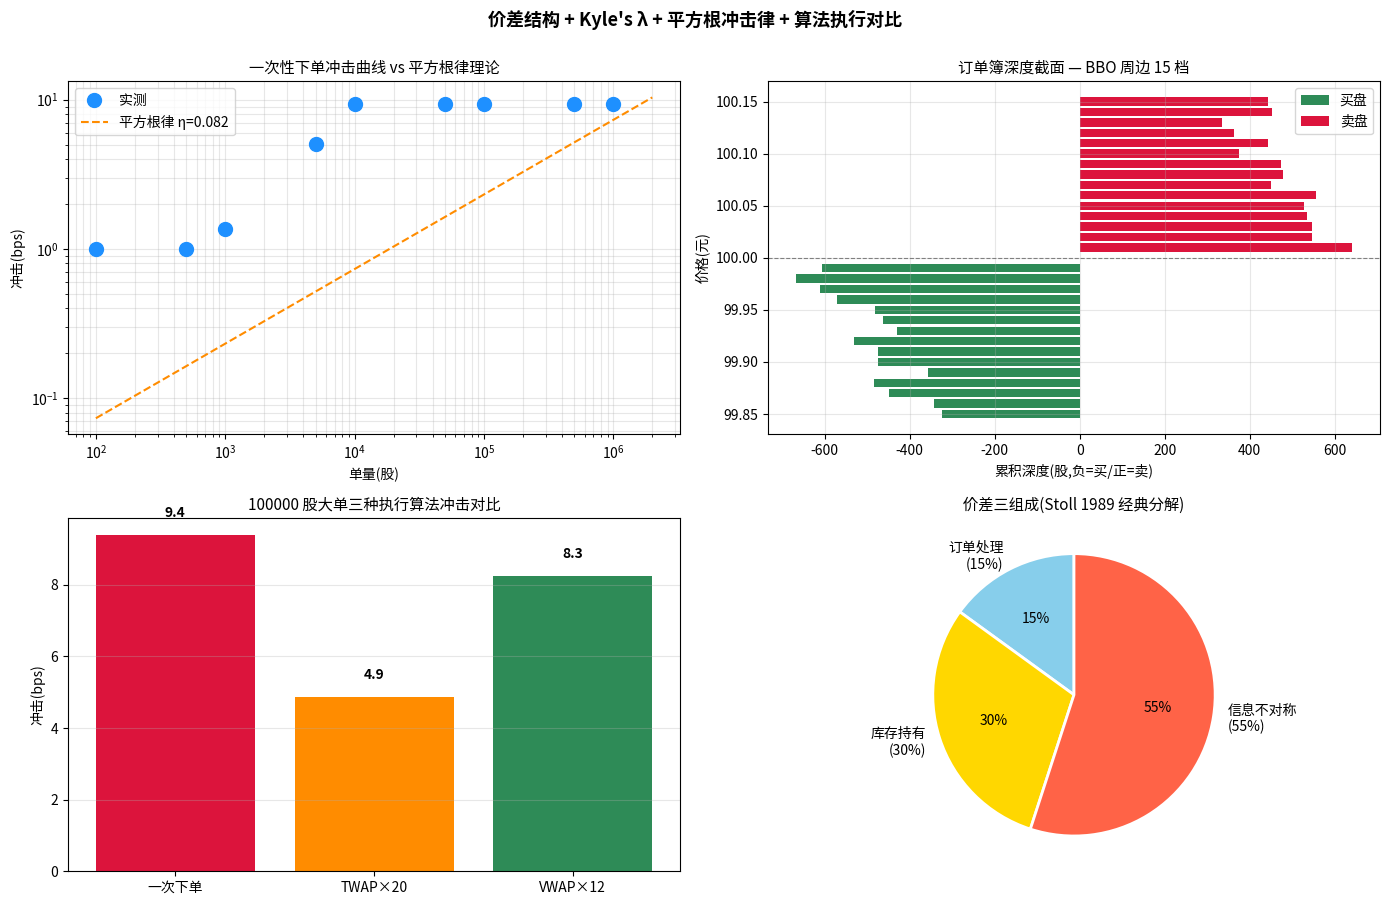

In [3]:
# day_023_impact_cost.py — 价差 / 流动性 / 冲击成本
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.random.seed(42)

# ============ 1. 模拟一个真实标的的订单簿 ============
init_mid = 100.0; tick = 0.01
# 在 mid 上下各 20 档挂限价单,深度服从指数衰减(BBO 附近浅,远档深)
DEPTH_PER_LEVEL = lambda lvl: int(500 * np.exp(-0.05 * lvl) + np.random.uniform(50, 200))
bids = {round(init_mid - tick * (i+1), 2): DEPTH_PER_LEVEL(i) for i in range(20)}
asks = {round(init_mid + tick * (i+1), 2): DEPTH_PER_LEVEL(i) for i in range(20)}

print('订单簿初始深度(前5档):')
print('  卖盘:', sorted(asks.items())[:5])
print('  买盘:', sorted(bids.items(), reverse=True)[:5])
print(f'初始 mid {init_mid:.2f} spread {tick:.2f} bps {tick/init_mid*10000:.1f}')

# ============ 2. 测一次性下单的冲击曲线 ============
def market_impact_sweep(book_asks, qty):
    """模拟市价买入 qty 股,返回 (vwap, last_fill_price, impact_bps)"""
    asks_copy = dict(book_asks)
    prices = sorted(asks_copy.keys())
    filled = 0; vwap_sum = 0; last_p = None
    for p in prices:
        if filled >= qty: break
        avail = asks_copy[p]
        take = min(avail, qty - filled)
        filled += take; vwap_sum += take * p; last_p = p
    if filled == 0:
        return None, None, None
    vwap = vwap_sum / filled
    impact_bps = (vwap - init_mid) / init_mid * 10000
    return vwap, last_p, impact_bps

qtys = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
impacts = []
print('\n一次性下单冲击曲线:')
print(f'{"单量":>10} {"VWAP":>10} {"末档价":>10} {"冲击(bps)":>12}')
for q in qtys:
    vwap, last_p, imp = market_impact_sweep(asks, q)
    if vwap is None:
        print(f'{q:>10} {"-":>10} {"-":>10} {"全部吃穿":>12}')
    else:
        impacts.append((q, vwap, last_p, imp))
        print(f'{q:>10} {vwap:>10.4f} {last_p:>10.2f} {imp:>12.2f}')

# ============ 3. 拟合平方根律:impact = η × √(q / V) ============
qty_arr = np.array([x[0] for x in impacts])
imp_arr = np.array([x[3] for x in impacts])
V_daily = 5_000_000   # 假设日均成交 500 万股
sigma_daily = 200      # 日波动 ≈ 200 bps(2%)
# Almgren 模型 impact = η × σ × √(q/V) ⇒ η = impact / (σ × √(q/V))
x = sigma_daily * np.sqrt(qty_arr / V_daily)
eta_fit = np.polyfit(x, imp_arr, 1)[0]
print(f'\n平方根律拟合 η = {eta_fit:.4f} (Almgren 经验值 0.1-0.5,在此区间则模型合理)')

# ============ 4. 对比一次下单 vs TWAP 分批 vs VWAP 分批 ============
QTY_LARGE = 100000

# 4.1 一次下单
vwap_one, _, imp_one = market_impact_sweep(asks, QTY_LARGE)
print(f'\n大单 {QTY_LARGE} 股执行对比:')
print(f'  一次下单:  VWAP {vwap_one:.4f} 冲击 {imp_one:.2f} bps')

# 4.2 TWAP 拆 20 份等间距,每份执行后订单簿『部分恢复』
BATCH_N = 20
twap_qty_per = QTY_LARGE // BATCH_N
asks_twap = dict(asks); twap_fills = []
for i in range(BATCH_N):
    vwap_b, _, imp_b = market_impact_sweep(asks_twap, twap_qty_per)
    if vwap_b is None: break
    twap_fills.append((twap_qty_per, vwap_b))
    # 简化模拟:每次下单消耗最浅档,但下一批前『恢复』40%
    prices_used = sorted(asks_twap.keys())
    for p in prices_used[:3]:
        if p in asks_twap:
            asks_twap[p] = int(asks_twap[p] * 0.6 + DEPTH_PER_LEVEL(0) * 0.4)
twap_vwap = sum(q*p for q,p in twap_fills) / sum(q for q,_ in twap_fills)
twap_imp = (twap_vwap - init_mid) / init_mid * 10000
print(f'  TWAP {BATCH_N} 份:VWAP {twap_vwap:.4f} 冲击 {twap_imp:.2f} bps')

# 4.3 VWAP 按假设成交量分布拆(早盘多 / 中午少 / 尾盘多)
vwap_dist = np.array([2,3,4,3,2,1.5,1.5,2,3,3.5,4,3.5])  # 12 个时段权重
vwap_dist = vwap_dist / vwap_dist.sum()
asks_vwap = dict(asks); vwap_fills = []
for w in vwap_dist:
    q = max(1, int(QTY_LARGE * w))
    vwap_b, _, imp_b = market_impact_sweep(asks_vwap, q)
    if vwap_b is None: break
    vwap_fills.append((q, vwap_b))
    prices_used = sorted(asks_vwap.keys())
    for p in prices_used[:3]:
        if p in asks_vwap:
            asks_vwap[p] = int(asks_vwap[p] * 0.5 + DEPTH_PER_LEVEL(0) * 0.5)
vwap_vwap = sum(q*p for q,p in vwap_fills) / sum(q for q,_ in vwap_fills)
vwap_imp = (vwap_vwap - init_mid) / init_mid * 10000
print(f'  VWAP {len(vwap_dist)} 段:VWAP {vwap_vwap:.4f} 冲击 {vwap_imp:.2f} bps')

savings = imp_one - vwap_imp
print(f'\n大单分批执行省下冲击成本 = {savings:.2f} bps ({savings/imp_one*100:.1f}%)')

# ============ 5. 可视化 ============
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 5.1 冲击曲线 + 平方根律理论曲线
qty_dense = np.logspace(2, 6.3, 50)
imp_theory = eta_fit * sigma_daily * np.sqrt(qty_dense / V_daily)
axes[0,0].loglog(qty_arr, imp_arr, 'o', markersize=10, color='#1e90ff', label='实测')
axes[0,0].loglog(qty_dense, imp_theory, '--', color='#ff8c00', label=f'平方根律 η={eta_fit:.3f}')
axes[0,0].set_title('一次性下单冲击曲线 vs 平方根律理论', fontsize=11)
axes[0,0].set_xlabel('单量(股)'); axes[0,0].set_ylabel('冲击(bps)')
axes[0,0].grid(alpha=0.3, which='both'); axes[0,0].legend()

# 5.2 订单簿深度可视化
prices_b = sorted(bids.keys(), reverse=True)[:15]; depths_b = [bids[p] for p in prices_b]
prices_a = sorted(asks.keys())[:15]; depths_a = [asks[p] for p in prices_a]
axes[0,1].barh(prices_b, [-d for d in depths_b], height=0.008, color='#2e8b57', label='买盘')
axes[0,1].barh(prices_a, depths_a, height=0.008, color='#dc143c', label='卖盘')
axes[0,1].axhline(init_mid, color='gray', linestyle='--', linewidth=0.8)
axes[0,1].set_title('订单簿深度截面 — BBO 周边 15 档', fontsize=11)
axes[0,1].set_xlabel('累积深度(股,负=买/正=卖)'); axes[0,1].set_ylabel('价格(元)')
axes[0,1].grid(alpha=0.3); axes[0,1].legend()

# 5.3 三种执行算法对比
labels = ['一次下单', f'TWAP×{BATCH_N}', f'VWAP×{len(vwap_dist)}']
imps = [imp_one, twap_imp, vwap_imp]
colors = ['#dc143c', '#ff8c00', '#2e8b57']
axes[1,0].bar(labels, imps, color=colors)
axes[1,0].set_title(f'{QTY_LARGE} 股大单三种执行算法冲击对比', fontsize=11)
axes[1,0].set_ylabel('冲击(bps)'); axes[1,0].grid(alpha=0.3, axis='y')
for i, v in enumerate(imps):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

# 5.4 价差三组成饼图(教学示意)
spread_components = [15, 30, 55]   # 处理 / 库存 / adverse selection 典型百分比
axes[1,1].pie(spread_components, labels=['订单处理\n(15%)','库存持有\n(30%)','信息不对称\n(55%)'],
              colors=['#87ceeb','#ffd700','#ff6347'], startangle=90,
              autopct='%1.0f%%', wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,1].set_title('价差三组成(Stoll 1989 经典分解)', fontsize=11)

plt.suptitle('价差结构 + Kyle\'s λ + 平方根冲击律 + 算法执行对比',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('chart_01.png', dpi=120, bbox_inches='tight')
print('图已保存 chart_01.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 1985 Kyle 论文 | 学术理论开山 | Albert Kyle 在 Econometrica 发表《Continuous Auctions and Insider Trading》,第一次把『单量推动价格』表达成数学模型 — Δprice = λ × Q。这开启了 market microstructure 学科,所有后续冲击模型都以此为基础。Kyle 自己后来在马里兰大学任教,但 Citadel 等顶级量化都重金挖他做顾问。 |
| 1998 LTCM 倒闭 | 长期资本 | LTCM 顶峰持有 1300 亿美元仓位,但都集中在窄利差套利标的上。1998 俄罗斯违约后 LTCM 需要快速平仓,但市场无法消化 — 想卖的标的没人接,实际冲击是模型预测的 5-10 倍。LTCM 几个月内 46 亿美元蒸发 — 这是冲击成本理论被极端事件碾压的最经典案例。 |
| 2000 Almgren-Chriss 论文 | 执行算法基石 | Robert Almgren 和 Neil Chriss 发表《Optimal Execution of Portfolio Transactions》,提出平方根冲击律 + IS 算法。这篇论文成为 algo trading 行业的圣经,高盛 / 摩根 / 花旗等顶级投资银行的执行台全部基于这套理论。Almgren 后来创业 Quantitative Brokers 做执行算法服务,服务对冲基金客户。 |
| 2010-05-06 闪崩 | 美股全市场 | Waddell & Reed 用 VWAP 算法卖 41亿美元 E-mini SP 期货,但算法参数设错(没设最大单量限制),9% 仓位在 20 分钟内全部冲击进市场。高频做市商先撤单避险,深度瞬间崩溃,1 万股市价单把价格推到 1 美分。这是冲击模型『假设深度稳定』在极端事件下失败的经典案例。 |
| 2015 中国股市暴跌 | 上证综指 / 中证500 | 千股跌停期间,机构大单想平仓没人接,挂跌停板等几天才成交。冲击成本无穷大(永远等不到成交)。这反映了 A 股涨跌停机制下的特殊冲击形态 — 平价无成交比有成交但冲击大更危险,因为你完全不能控制风险敞口。 |


## 常见坑

### ⚠ 01. 把手续费当主要成本,忽略 IS 滑点

散户最大隐性成本不是手续费,而是 implementation shortfall。一笔 50 万元市价单 IS 50 基点 = 2500 元损失,远超手续费 50 元。新手长期不记录 IS,根本不知道自己每笔在隐性亏多少。**正确做法**:每笔单记录 arrival price + 实际均价,月度统计平均 IS。

### ⚠ 02. 线性外推冲击 — 1 万股冲击 10 基点,10 万股就 100 基点

实际是平方根律,10 万股冲击大约 √10 倍 ≈ 32 基点,不是 100 基点。线性外推会高估自己冲击成本,导致过度保守。**正确做法**:用 √-law,impact ∝ √Q,单量翻 N 倍冲击翻 √N 倍。

### ⚠ 03. 用 TWAP 在低成交量时段下大单

TWAP 把单量平均分到时间上,但成交量分布不均匀 — 中午低、开盘 / 收盘高。中午下大单冲击放大数倍。**正确做法**:用 VWAP 跟随成交量分布,或者避开中午低成交时段。

### ⚠ 04. 事件前后 spread 走宽以为是限流

事件前 spread 走宽是 adverse selection 上升的信号 — 做市商在保护自己。这时候继续按平时单量进出会被反向收割。**正确做法**:看到 spread 突然走宽 2 倍以上,把单量缩小或者直接退出,等市场冷却。

### ⚠ 05. 把日均成交量当永久参数

Q/V 是冲击的关键变量,但 V 在不同日子能差 5-10 倍。淡季 / 节前 / 极端事件后 V 会暴跌,你按平时 V 估的冲击会严重低估。**正确做法**:看最近 5 个交易日的 V 中位数,极端事件后看实时累计成交。

## 实战 SOP · 冲击成本实战 SOP

1. 下单前估 Q/V 比例:< 1% 直接下,1-5% 拆 5-10 份,5-10% 用 VWAP 算法,> 10% 必拆当日
2. 永远记录 arrival price + 实际均价,月度统计 IS,这是你的执行能力核心 KPI
3. 事件前后(财报 / 央行公告 / 黑天鹅)spread 走宽 = adverse selection,缩量或暂停
4. 拆单按平方根律分散,不要线性等量 — 5 份每份 1 万股 ≠ 单笔 5 万股冲击的 1/5
5. 限价单挂 BBO 内侧 1 档(price improvement),抢 rank 1 同时降低冲击
6. 中午低成交时段避开下大单(11:00-13:00 是典型低谷)
7. 极端事件后看实时 V,不要按历史平均 V 估冲击 — 流动性枯竭时 V 能跌 90%

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. spread 三组成:订单处理 15% + 库存持有 30% + 信息不对称 55%(Stoll 1989 经典分解)
3. Kyle's lambda(1985):Δmid = λ × Q,衡量市场对单量的瞬时弹性,大盘 λ 极小、小盘 λ 大
4. Almgren-Chriss 平方根律:Impact = η × σ × √(Q/V),单量翻 100 倍冲击只翻 10 倍
5. Implementation Shortfall:(实际均价 - arrival price) / arrival price × 10000 bps,衡量执行能力
6. TWAP / VWAP / IS 三种算法 — 单量小用 TWAP 简单,单量大用 VWAP 跟成交,极致优化用 IS
7. 散户轻量化:拆 5-10 份 + 限价单 BBO 内侧 + 间隔几分钟下一份 + 记录 IS
8. 极端事件下流动性枯竭,所有冲击模型失效(LTCM / 2010 闪崩 / 2015 千股跌停)

## 自测题

**Q1.** 价差为什么不会归零?三个组成各占什么比例?(提示:订单处理 / 库存 / adverse selection)

**Q2.** Kyle's lambda 的经济含义是什么?lambda 大代表市场流动性好还是差?(提示:Δprice = λ × Q)

**Q3.** 你下 10 万股市价单冲击是 30 基点。按平方根律,下 1 万股的冲击大约多少?100 万股大约多少?(提示:√10 / √100)

**Q4.** Implementation Shortfall 怎么计算?为什么它比手续费更重要?(提示:arrival price 锚点,基点 vs 单笔费用对比)

**Q5.** 你要执行 200 万元单子(占日均成交量 8%),选 TWAP / VWAP / IS 哪个算法?为什么?(提示:Q/V 大于 5% 时选 VWAP 跟随成交量分布)

把答案写下来,3 天后再回看。

## 下一节预告

**Day 024 · 撮合机制全景** (Matching Mechanics)

第 24 课讲撮合机制全景 — 我们已经看过订单簿和冲击成本,接下来从交易所内部角度看撮合引擎怎么工作。会自己写一个简易撮合引擎(限价 / 市价 / 撤单都支持),理解集合竞价 vs 连续竞价两种模式,并对比 FIFO 价格-时间优先 和 pro-rata 按比例分配两种规则。

## 推荐阅读

- Kyle《Continuous Auctions and Insider Trading》(Econometrica 1985)— 市场微结构开山论文,lambda 模型源头
- Almgren, Chriss《Optimal Execution of Portfolio Transactions》(Journal of Risk 2000)— 平方根冲击律 + IS 算法,执行算法行业圣经
- Stoll《Inferring the Components of the Bid/Ask Spread》(Journal of Finance 1989)— spread 三组成实证分解
- Perold《The Implementation Shortfall: Paper Versus Reality》(JPM 1988)— IS 概念提出 + 大单交易行业基础
- Python 工具栈:pandas + numpy + cvxpy 模拟 IS 算法(线性优化);真实数据可用 Tickdata / Refinitiv;本课用合成订单簿避免数据门槛